In [1]:
import pandas as pd
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random 

from loss_cgmvae import *

In [2]:
random_seed = 10
np.random.seed = random_seed
random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)

In [3]:
def generate_2_gmm_centers(latent_dims, range_start):
    unique_pairs = []
    for _ in range(latent_dims):
        num1 = random.uniform(range_start, range_start+10)
        num2 = random.uniform(range_start+10, range_start+20)
        unique_pairs.append((num1, num2))
    gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
    return gmm_centers

In [4]:
def gaussian_sample(latent_dims, num_samples, gmm_std):
    startpoint = random.randint(-30,0)
    gmm_centers = generate_2_gmm_centers(latent_dims, startpoint)
    #print(gmm_centers.numpy())
    print(gmm_centers.shape)
    print(f"Standard deviation used: {gmm_std}")
    samples, components = draw_gmm_samples(num_samples, gmm_centers, gmm_std)
    data = samples.numpy()
    for dim in range(data.shape[1]):
        df = pd.DataFrame({'sample': data[:, dim], 'component': components})
        plt.figure(figsize=(5, 3))
        for comp_id in sorted(df['component'].unique()):
            subset = df[df['component'] == comp_id]
            sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
        plt.title("Dim" + str(dim+1) + " KDE per GMM Component")
        plt.show()
    return gmm_centers.numpy(), df, gmm_std

Calculate gaussian mixture centers

torch.Size([2, 8])
Standard deviation used: 6


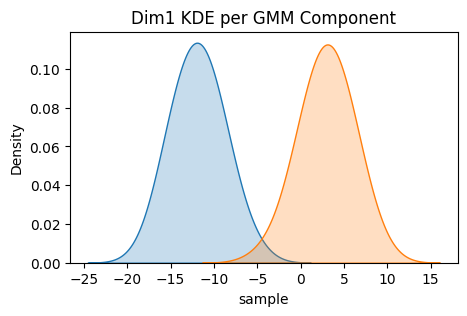

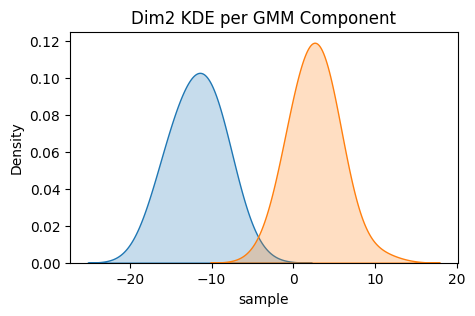

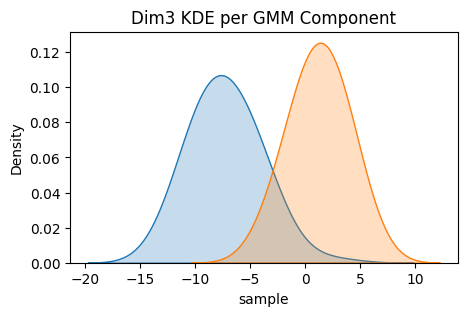

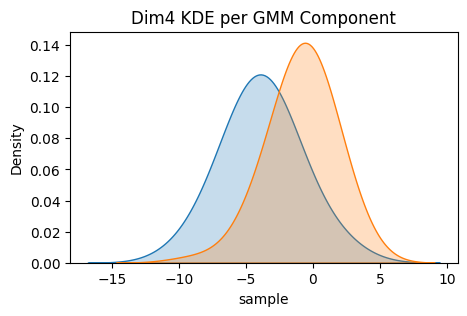

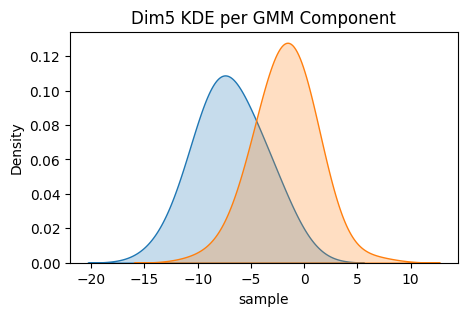

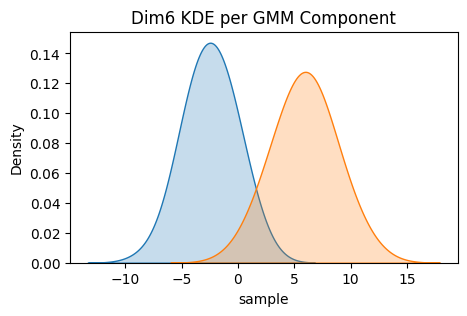

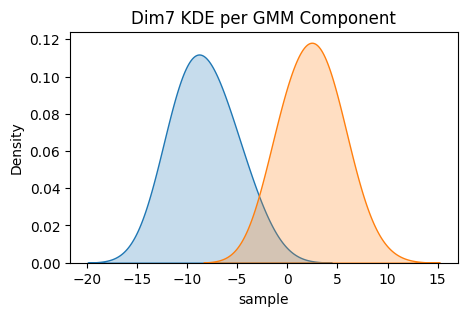

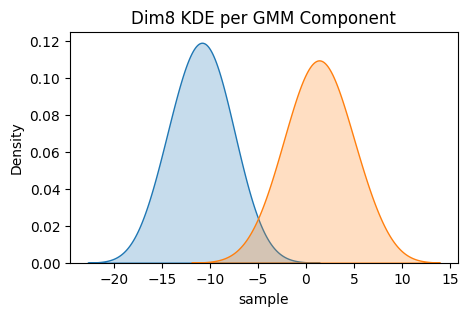

In [5]:
num_samples = 128
gmm_std = 6
latent_dims = 8
gmm_center, temp_data, gmm_std = gaussian_sample(latent_dims, num_samples, gmm_std)

Save the gaussian mixture centers to csv

In [6]:
center_names = [f'c{i+1}' for i in range(latent_dims)]
df_gmm_centers = pd.DataFrame(gmm_center, columns=center_names)
df_gmm_centers

,c1,c2,c3,c4,c5,c6,c7,c8
0,-11.674150,-11.851676,-7.087036,-3.893812,-7.099144,-2.476008,-8.388413,-10.613108
1,2.825617,2.625805,0.775207,-1.655964,-1.239107,5.455467,2.203962,1.550817


In [7]:
df_gmm_centers.to_csv('/home/rachel/Desktop/mm-vae_ext2/data/gmm_centers_ld8_std10_v3.csv', index=False)